# Notebook 5: Evaluating Generated Materials -- MLIPs

**APS Tutorial T4 -- Generative AI for Physics: From Models to Materials**

In this notebook you will learn to:
- Use **CHGNet** (a universal machine-learning interatomic potential) for fast property prediction
- **Relax** crystal structures to find local energy minima
- Evaluate **thermodynamic stability** via the convex hull (energy above hull)
- **Screen SCIGEN-generated materials** across structural constraint types
- Understand the full **Generate -> Screen -> Validate** pipeline

> **Prerequisites:** Run `00_setup.ipynb` first. Notebook 04 is recommended but not required.

In [ ]:
# takes long (~1-3 min) — installs dependencies
# --- Run once per Colab session (skip if you already ran 00_setup.ipynb) ---
import os, shutil, subprocess, sys

REPO_URL = 'https://github.com/RyotaroOKabe/APS_demo_SCIGEN.git'
PROJECT_DIR = '/content/APS_demo_SCIGEN'

# Clone repo if needed
if not os.path.exists(os.path.join(PROJECT_DIR, '.git')):
    if os.path.exists(PROJECT_DIR):
        shutil.rmtree(PROJECT_DIR)
    os.system(f'git clone {REPO_URL} {PROJECT_DIR}')

# Install all tutorial dependencies from the shared requirements file
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       '-r', f'{PROJECT_DIR}/requirements-colab.txt'])
os.environ.setdefault('PROJECT_ROOT', PROJECT_DIR)
print('Ready.')

Ready.


---
## 5.1 The evaluation problem

Generating crystal structures is only half the job. After generation, we need to ask:

1. **Is this structure physically reasonable?** (sensible bond lengths, coordination)
2. **Is it thermodynamically stable?** (low energy, near the convex hull)
3. **Does it have interesting properties?** (magnetic, electronic, mechanical)

### 5.1.1 The traditional approach: DFT
Density Functional Theory (DFT) gives accurate energies and forces, but it's
**expensive** — each structure takes minutes to hours on a supercomputer.
If you generated 10,000 candidates, DFT relaxation could take weeks.

### 5.1.2 The modern approach: MLIPs
Machine Learning Interatomic Potentials are trained on DFT data and can predict
energies/forces/stresses in **seconds** — 1000x faster than DFT.
They enable rapid screening of large candidate sets.

---
## 5.2 CHGNet: a universal machine-learning interatomic potential

**CHGNet** (Crystal Hamiltonian Graph Neural Network) is a pretrained GNN that
predicts DFT-level properties for **any inorganic material** — without running
an actual DFT calculation.

| What it predicts | Typical accuracy |
|-----------------|-----------------|
| **Energy** (eV/atom) | ~30 meV/atom MAE vs. DFT |
| **Forces** (eV/Å) | ~70 meV/Å MAE |
| **Stress** (GPa) | ~0.3 GPa MAE |
| **Magnetic moments** (μ_B) | Semi-quantitative |

CHGNet was trained on **over 1.5 million DFT calculations** from the Materials
Project (MP-2021 GGA/GGA+U). Its key advantage: a single forward pass takes
milliseconds on GPU, compared to hours for a DFT calculation — enabling rapid
screening of thousands of candidate materials.

**Paper:** Deng et al., "CHGNet as a pretrained universal neural network potential
for charge-informed atomistic modelling," *Nature Machine Intelligence* 5, 1031 (2023).

In [ ]:
# takes long (~30-60 sec) — downloads CHGNet model weights
from chgnet.model.model import CHGNet

chgnet = CHGNet.load()
print(f'CHGNet loaded: {sum(p.numel() for p in chgnet.parameters()):,} parameters')

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
CHGNet loaded: 412,525 parameters


---
## 5.3 Predict properties for a test structure

Let's start with a known, stable structure from the MP-20 test set. We'll
predict its energy, forces, stress tensor, and magnetic moments using CHGNet
and compare against the DFT reference values stored in the dataset.

This serves as a **sanity check**: if CHGNet predictions are reasonable for known
structures, we can trust it to screen unknown (generated) structures.

In [ ]:
import os
import pandas as pd
from pymatgen.core import Structure

PROJECT_DIR = os.environ.get('PROJECT_ROOT', '/content/APS_demo_SCIGEN')
df = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'mp_20', 'test.csv'))

# Pick a structure
row = df.iloc[0]
struct = Structure.from_str(row['cif'], fmt='cif')

print(f'Structure: {row["pretty_formula"]} ({row["material_id"]})')
print(f'Atoms: {struct.num_sites}')
print(f'DFT formation energy: {row["formation_energy_per_atom"]:.4f} eV/atom')

Structure: GaTe (mp-10009)
Atoms: 8
DFT formation energy: -0.5751 eV/atom


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [ ]:
# Predict with CHGNet
prediction = chgnet.predict_structure(struct)

print(f'CHGNet predictions for {row["pretty_formula"]}:')
print(f'  Energy:  {prediction["e"]:>10.4f} eV/atom')
print(f'  Forces:  max |F| = {abs(prediction["f"]).max():.4f} eV/Å')
print(f'  Stress:  {prediction["s"].diagonal().tolist()}')
if 'm' in prediction:
    print(f'  Magmom:  {prediction["m"].tolist()}')

/usr/local/lib/python3.12/dist-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


CHGNet predictions for GaTe:
  Energy:     -3.6323 eV/atom
  Forces:  max |F| = 0.0550 eV/Å
  Stress:  [-0.10584522038698196, -0.10583381354808807, 0.5815281271934509]
  Magmom:  [0.015011757612228394, 0.015011653304100037, 0.01501186192035675, 0.015011712908744812, 0.005475960671901703, 0.005475923418998718, 0.005475945770740509, 0.005475960671901703]


---
## 5.4 Structure relaxation from a perturbed state

To demonstrate relaxation clearly, we start from a **deliberately perturbed**
structure — we take a known stable crystal and displace atoms randomly by ~0.3 Å.
This simulates what a generated (unrelaxed) structure might look like.

Then we relax with CHGNet and watch:
1. The **energy decrease** step by step toward equilibrium
2. The **atoms settle** back to their stable positions

In [ ]:
# takes long (~5-30 sec) — relaxes crystal structure with CHGNet
import numpy as np
from chgnet.model.dynamics import StructOptimizer

# --- Create a perturbed (unstable) structure ---
np.random.seed(42)
perturbed = struct.copy()

# Add random displacements of ~0.3 Å to each atom
noise_amplitude = 0.3  # Å
cart_coords = perturbed.cart_coords.copy()
noise = noise_amplitude * np.random.randn(*cart_coords.shape)
for i, site in enumerate(perturbed):
    perturbed.translate_sites(i, noise[i], frac_coords=False)

# Check: energy of perturbed structure is HIGHER than the original
pred_orig = chgnet.predict_structure(struct)
pred_pert = chgnet.predict_structure(perturbed)
print(f'Original (equilibrium):  E = {pred_orig["e"]:.4f} eV/atom,  max|F| = {abs(pred_orig["f"]).max():.4f} eV/Å')
print(f'Perturbed (noisy):       E = {pred_pert["e"]:.4f} eV/atom,  max|F| = {abs(pred_pert["f"]).max():.2f} eV/Å')
print(f'Energy increase from perturbation: {pred_pert["e"] - pred_orig["e"]:.4f} eV/atom')
print(f'\nRelaxing perturbed structure with CHGNet...')

# --- Relax the perturbed structure ---
optimizer = StructOptimizer()
result = optimizer.relax(perturbed, verbose=True)

relaxed = result['final_structure']
e_final = result['trajectory'].energies[-1] / relaxed.num_sites
print(f'\nRelaxation complete:')
print(f'  Perturbed energy: {pred_pert["e"]:.4f} eV/atom')
print(f'  Relaxed energy:   {e_final:.4f} eV/atom')
print(f'  DFT reference:    {row["formation_energy_per_atom"]:.4f} eV/atom (formation energy)')
print(f'  Energy drop:      {pred_pert["e"] - e_final:.4f} eV/atom')

Original (equilibrium):  E = -3.6323 eV/atom,  max|F| = 0.0550 eV/Å
Perturbed (noisy):       E = -2.8614 eV/atom,  max|F| = 19.75 eV/Å
Energy increase from perturbation: 0.7709 eV/atom

Relaxing perturbed structure with CHGNet...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
      Step     Time          Energy          fmax
FIRE:    0 12:02:23      -22.890896       23.387553
FIRE:    1 12:02:24      -26.782619        6.219686
FIRE:    2 12:02:24      -27.784229        2.368717
FIRE:    3 12:02:24      -28.074852        2.719335
FIRE:    4 12:02:25      -28.192286        2.095320
FIRE:    5 12:02:25      -28.318443        1.204924
FIRE:    6 12:02:25      -28.318022        1.192111
FIRE:    7 12:02:25      -28.325073        1.169525
FIRE:    8 12:02:25      -28.338562        1.102934
FIRE:    9 12:02:26      -28.357363        1.022620
FIRE:   10 12:02:26      -28.380253        0.941609
FIRE:   11 12:02:27      -28.406313        0.859449
FIRE:   12 12:02:28   

In [ ]:
# Compare: how close did relaxation get to the original equilibrium structure?
print('=== Comparison: perturbed → relaxed vs. original equilibrium ===\n')

print('Lattice parameter changes (relaxed vs. original):')
for param in ['a', 'b', 'c', 'alpha', 'beta', 'gamma']:
    orig = getattr(struct.lattice, param)
    relax = getattr(relaxed.lattice, param)
    unit = 'Å' if param in ['a', 'b', 'c'] else '°'
    print(f'  {param:>5s}: orig={orig:8.3f}  relaxed={relax:8.3f} {unit}  (Δ = {relax - orig:+.4f})')

# Displacement: perturbed → relaxed (how far did atoms move during relaxation?)
disp_relax = np.linalg.norm(relaxed.cart_coords - perturbed.cart_coords, axis=1)
# Displacement: relaxed → original (how close to equilibrium did we get?)
disp_equil = np.linalg.norm(relaxed.cart_coords - struct.cart_coords, axis=1)
# Original perturbation magnitude
disp_noise = np.linalg.norm(perturbed.cart_coords - struct.cart_coords, axis=1)

species_list = [str(s.specie) for s in struct]
print(f'\nPer-atom displacements:')
print(f'  {"Atom":<6} {"Perturbation":<16} {"Relaxation move":<18} {"Residual from eq.":<18}')
for i in range(struct.num_sites):
    print(f'  {species_list[i]:<6} {disp_noise[i]:>10.4f} Å      {disp_relax[i]:>10.4f} Å        {disp_equil[i]:>10.4f} Å')

print(f'\nMean perturbation:      {disp_noise.mean():.4f} Å')
print(f'Mean residual from eq.: {disp_equil.mean():.4f} Å')
print(f'Recovery ratio:         {(1 - disp_equil.mean() / disp_noise.mean()) * 100:.1f}%')

=== Comparison: perturbed → relaxed vs. original equilibrium ===

Lattice parameter changes (relaxed vs. original):
      a: orig=   4.135  relaxed=   4.169 Å  (Δ = +0.0343)
      b: orig=   4.135  relaxed=   4.164 Å  (Δ = +0.0298)
      c: orig=  18.426  relaxed=  18.369 Å  (Δ = -0.0562)
  alpha: orig=  90.000  relaxed=  89.027 °  (Δ = -0.9729)
   beta: orig=  90.000  relaxed=  91.062 °  (Δ = +1.0624)
  gamma: orig= 120.000  relaxed= 120.202 °  (Δ = +0.2017)

Per-atom displacements:
  Atom   Perturbation     Relaxation move    Residual from eq. 
  Ga         0.2484 Å          0.3083 Å            0.2692 Å
  Ga         0.4676 Å          0.4236 Å            0.3445 Å
  Ga         0.5452 Å          0.5275 Å            0.3680 Å
  Ga         0.2556 Å          0.3392 Å            0.2101 Å
  Te         0.7762 Å          0.5327 Å            0.3840 Å
  Te         0.3601 Å          0.1987 Å            0.1780 Å
  Te         0.6686 Å          0.4130 Å            0.2627 Å
  Te         0.4332 Å      

### 5.4.1 Relaxation trajectory

Let's visualize how the energy decreased during relaxation. A well-behaved
relaxation shows rapid energy decrease in the first few steps, then convergence
to a plateau. The force magnitude should decrease monotonically toward zero.

If the energy oscillates or doesn't converge, the structure may be near a saddle
point or the step size may be too large.

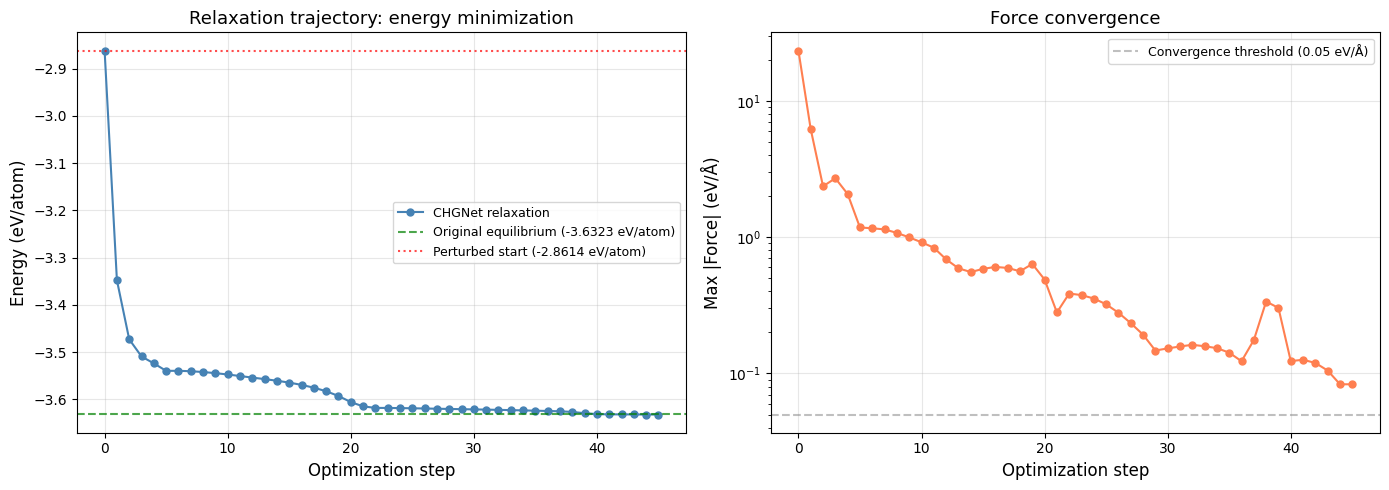

Converged in 46 steps
Energy drop: 0.7710 eV/atom


In [ ]:
# takes long (~5-30 sec) — plots relaxation energy trajectory
import matplotlib.pyplot as plt

# Plot energy trajectory during relaxation
energies_traj = result['trajectory'].energies
n_atoms_relax = relaxed.num_sites
e_per_atom = [e / n_atoms_relax for e in energies_traj]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Energy trajectory
ax = axes[0]
steps = range(len(e_per_atom))
ax.plot(steps, e_per_atom, 'o-', color='steelblue', markersize=5, linewidth=1.5,
        label='CHGNet relaxation')
ax.axhline(pred_orig['e'], color='green', linestyle='--', alpha=0.7,
           label=f'Original equilibrium ({pred_orig["e"]:.4f} eV/atom)')
ax.axhline(pred_pert['e'], color='red', linestyle=':', alpha=0.7,
           label=f'Perturbed start ({pred_pert["e"]:.4f} eV/atom)')
ax.set_xlabel('Optimization step', fontsize=12)
ax.set_ylabel('Energy (eV/atom)', fontsize=12)
ax.set_title('Relaxation trajectory: energy minimization', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Max force trajectory (if available)
ax2 = axes[1]
try:
    forces_traj = result['trajectory'].forces
    max_forces = [np.max(np.linalg.norm(f, axis=1)) for f in forces_traj]
    ax2.semilogy(range(len(max_forces)), max_forces, 'o-', color='coral',
                 markersize=5, linewidth=1.5)
    ax2.axhline(0.05, color='gray', linestyle='--', alpha=0.5,
                label='Convergence threshold (0.05 eV/Å)')
    ax2.set_xlabel('Optimization step', fontsize=12)
    ax2.set_ylabel('Max |Force| (eV/Å)', fontsize=12)
    ax2.set_title('Force convergence', fontsize=13)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
except Exception:
    ax2.text(0.5, 0.5, 'Force trajectory not available', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print(f'Converged in {len(energies_traj)} steps')
print(f'Energy drop: {e_per_atom[0] - e_per_atom[-1]:.4f} eV/atom')

### 5.4.2 Structure animation during relaxation

The animation below shows three things simultaneously:
1. **Colored spheres** — current atomic positions at each optimization step
2. **Red arrows** — forces acting on each atom (direction the optimizer pushes them)
3. **Small green dots** — equilibrium positions (from the original unperturbed structure)

Watch how the atoms (spheres) migrate toward the equilibrium positions (green dots)
while the force arrows shrink to zero.

In [ ]:
# takes long (~5-30 sec) — renders relaxation animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# Extract trajectory frames
traj = result['trajectory']
n_frames = len(traj.energies)

# Select key frames (evenly spaced, max 20 frames for smooth animation)
n_show = min(n_frames, 20)
frame_indices = np.linspace(0, n_frames - 1, n_show, dtype=int)

# Equilibrium positions (original unperturbed structure)
equil_pos = struct.cart_coords

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Get coordinate range for consistent axis limits
all_positions = np.array([traj.atom_positions[i] for i in frame_indices])
pad = 0.5
x_lim = (all_positions[:, :, 0].min() - pad, all_positions[:, :, 0].max() + pad)
y_lim = (all_positions[:, :, 1].min() - pad, all_positions[:, :, 1].max() + pad)
z_lim = (all_positions[:, :, 2].min() - pad, all_positions[:, :, 2].max() + pad)

# Force scale: normalize arrows for visibility
has_forces = hasattr(traj, 'forces') and traj.forces is not None and len(traj.forces) > 0
if has_forces:
    all_forces = np.array([traj.forces[i] for i in frame_indices])
    max_force_global = np.max(np.linalg.norm(all_forces, axis=2))
    arrow_scale = 1.0 / max(max_force_global, 1e-6)  # normalize to ~1 Å length

species_list = [str(s.specie) for s in struct]
unique_el = sorted(set(species_list))
cmap_colors = plt.cm.tab10(np.linspace(0, 0.9, max(len(unique_el), 1)))
color_map = {el: cmap_colors[i] for i, el in enumerate(unique_el)}

def update(frame_num):
    ax.clear()
    idx = frame_indices[frame_num]
    positions = traj.atom_positions[idx]
    energy = traj.energies[idx] / struct.num_sites

    # Draw equilibrium positions (small green dots)
    ax.scatter(equil_pos[:, 0], equil_pos[:, 1], equil_pos[:, 2],
               s=30, c='limegreen', alpha=0.6, marker='o',
               edgecolors='green', linewidths=0.5, label='Equilibrium')

    # Draw current atom positions
    for el in unique_el:
        mask = [s == el for s in species_list]
        coords = positions[mask]
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                   s=200, c=[color_map[el]], label=el,
                   alpha=0.85, edgecolors='k', linewidths=0.5)

    # Draw force arrows
    if has_forces and idx < len(traj.forces):
        forces = traj.forces[idx]
        for i in range(len(positions)):
            f = forces[i]
            f_mag = np.linalg.norm(f)
            if f_mag > 0.01:  # skip tiny forces
                ax.quiver(positions[i, 0], positions[i, 1], positions[i, 2],
                          f[0] * arrow_scale, f[1] * arrow_scale, f[2] * arrow_scale,
                          color='red', alpha=0.7, linewidth=1.5,
                          arrow_length_ratio=0.3)

    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim); ax.set_zlim(*z_lim)
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)'); ax.set_zlabel('z (Å)')

    # Build legend without duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=7)

    max_f = np.max(np.linalg.norm(traj.forces[idx], axis=1)) if has_forces and idx < len(traj.forces) else 0
    ax.set_title(f'Step {idx}/{n_frames-1}  |  E = {energy:.4f} eV/atom  |  max|F| = {max_f:.3f} eV/Å',
                 fontsize=10)

anim = FuncAnimation(fig, update, frames=n_show, interval=400, repeat=True)
plt.close(fig)

try:
    display(HTML(anim.to_jshtml()))
except Exception:
    # Fallback: show first, middle, and last frames as static plots
    print('Animation display not supported — showing key frames instead.')
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})
    for ax2, label, fi in zip(axes2, ['Initial (perturbed)', 'Mid relaxation', 'Final (relaxed)'],
                               [0, n_show // 2, n_show - 1]):
        idx = frame_indices[fi]
        positions = traj.atom_positions[idx]
        energy = traj.energies[idx] / struct.num_sites
        # Equilibrium
        ax2.scatter(equil_pos[:, 0], equil_pos[:, 1], equil_pos[:, 2],
                    s=30, c='limegreen', alpha=0.6, edgecolors='green', linewidths=0.5)
        # Current positions
        for el in unique_el:
            mask = [s == el for s in species_list]
            coords = positions[mask]
            ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                       s=200, c=[color_map[el]], label=el,
                       alpha=0.85, edgecolors='k', linewidths=0.5)
        # Forces
        if has_forces and idx < len(traj.forces):
            forces = traj.forces[idx]
            for i in range(len(positions)):
                f = forces[i]
                if np.linalg.norm(f) > 0.01:
                    ax2.quiver(positions[i, 0], positions[i, 1], positions[i, 2],
                              f[0]*arrow_scale, f[1]*arrow_scale, f[2]*arrow_scale,
                              color='red', alpha=0.7, linewidth=1.5, arrow_length_ratio=0.3)
        ax2.set_xlim(*x_lim); ax2.set_ylim(*y_lim); ax2.set_zlim(*z_lim)
        ax2.set_xlabel('x (Å)'); ax2.set_ylabel('y (Å)'); ax2.set_zlabel('z (Å)')
        ax2.set_title(f'{label}\n(step {idx}, E={energy:.4f})', fontsize=10)
    plt.tight_layout()
    plt.show()

print('Green dots = equilibrium positions | Red arrows = forces | Spheres = current positions')

Green dots = equilibrium positions | Red arrows = forces | Spheres = current positions


---
## 5.5 Batch evaluation: CHGNet on the MP-20 test set

To assess CHGNet's accuracy systematically, we predict the formation energy
for multiple structures from the MP-20 test set and compare against their
DFT reference values. This gives us a **parity plot** (predicted vs. actual)
and a quantitative error metric (MAE).

Good agreement here gives us confidence to use CHGNet for screening generated
structures, where no DFT reference exists.

In [ ]:
# takes long (~30-90 sec) — batch CHGNet predictions on test structures
import matplotlib.pyplot as plt
import time
import numpy as np

# Evaluate the first 20 structures in the test set
n_eval = min(20, len(df))
energies_chgnet = []
energies_dft = []
formulas = []

# Compute CHGNet elemental reference energies for formation energy calculation
# (energy of each element in its standard bulk form)
from pymatgen.core import Structure, Lattice, Element

def get_elemental_ref_energies(chgnet_model):
    """Get CHGNet total energy per atom for common elemental reference structures."""
    refs = {}
    # Use simple structures as references
    # In practice, the MP elemental references are more accurate,
    # but this gives a reasonable approximation for comparison
    for el_symbol in ['Li', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ti', 'V', 'Cr',
                      'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se',
                      'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag',
                      'Cd', 'In', 'Sn', 'Sb', 'Te', 'Cs', 'Ba', 'La', 'Hf', 'Ta',
                      'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Pb', 'Bi',
                      'O', 'S', 'N', 'F', 'Cl', 'Br', 'I', 'P', 'C', 'B', 'H']:
        try:
            el = Element(el_symbol)
            # BCC structure as rough reference
            lat = Lattice.cubic(3.0)
            s = Structure(lat, [el_symbol, el_symbol], [[0,0,0], [0.5,0.5,0.5]])
            pred = chgnet_model.predict_structure(s)
            refs[el_symbol] = float(pred['e'])
        except:
            pass
    return refs

print('Computing elemental reference energies...')
elem_refs = get_elemental_ref_energies(chgnet)
print(f'  References computed for {len(elem_refs)} elements')

start = time.time()
for i in range(n_eval):
    row = df.iloc[i]
    try:
        s = Structure.from_str(row['cif'], fmt='cif')
        pred = chgnet.predict_structure(s)

        # Compute formation energy: E_total - sum(x_i * E_ref_i)
        total_e = float(pred['e'])  # eV/atom
        comp = s.composition.fractional_composition
        ref_sum = sum(comp[el] * elem_refs.get(str(el), 0) for el in comp)
        form_e = total_e - ref_sum

        energies_chgnet.append(form_e)
        energies_dft.append(row['formation_energy_per_atom'])
        formulas.append(row['pretty_formula'])
    except Exception as e:
        print(f'  Skipping {row["pretty_formula"]}: {e}')

elapsed = time.time() - start
print(f'Evaluated {len(energies_chgnet)} structures in {elapsed:.1f}s')
print(f'({elapsed/len(energies_chgnet)*1000:.0f} ms per structure)')

Computing elemental reference energies...
  References computed for 59 elements


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


Evaluated 20 structures in 0.9s
(44 ms per structure)


### 5.5.1 Speed comparison: DFT vs. CHGNet

The bar chart below illustrates the dramatic speed difference. A single DFT
calculation (VASP/Quantum ESPRESSO) typically takes **1–10 hours** per structure
depending on system size and accuracy settings. CHGNet predicts the same
properties in **under 1 second**.

For screening 10,000 SCIGEN-generated candidates:
- DFT: ~10,000 hours (~1 year of CPU time)
- CHGNet: ~3 hours on a single GPU

This **~3,000× speedup** is what makes MLIP-based screening practical for
generative materials discovery.

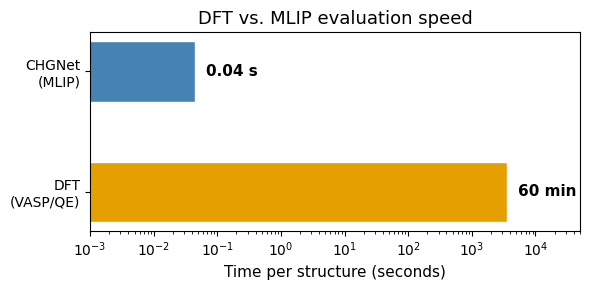

CHGNet is ~81096x faster than DFT for energy evaluation


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

methods = ['DFT\n(VASP/QE)', 'CHGNet\n(MLIP)']
times = [3600, elapsed / len(energies_chgnet)]  # seconds per structure
colors = ['#E69F00', 'steelblue']

bars = ax.barh(methods, times, color=colors, edgecolor='white', height=0.5)
ax.set_xscale('log')
ax.set_xlabel('Time per structure (seconds)', fontsize=11)
ax.set_title('DFT vs. MLIP evaluation speed', fontsize=13)

# Annotate bars
for bar, t in zip(bars, times):
    if t >= 60:
        label = f'{t/60:.0f} min'
    else:
        label = f'{t:.2f} s'
    ax.text(bar.get_width() * 1.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0.001, 50000)
plt.tight_layout()
plt.show()

speedup = 3600 / (elapsed / len(energies_chgnet))
print(f'CHGNet is ~{speedup:.0f}x faster than DFT for energy evaluation')

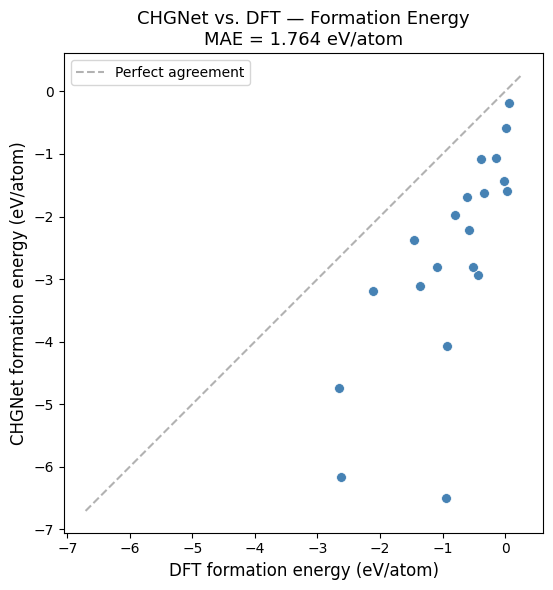

Note: CHGNet elemental references are approximate (BCC structures).
For production use, use MP-computed elemental reference energies.


In [ ]:
if not energies_dft:
    print('No data — run the batch evaluation cell above first.')
else:
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(energies_dft, energies_chgnet, s=50, c='steelblue',
               edgecolors='white', linewidths=0.5)

    # Diagonal line
    all_vals = energies_dft + energies_chgnet
    lims = [min(all_vals) - 0.2, max(all_vals) + 0.2]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='Perfect agreement')

    # Compute MAE
    mae = np.mean(np.abs(np.array(energies_dft) - np.array(energies_chgnet)))

    ax.set_xlabel('DFT formation energy (eV/atom)', fontsize=12)
    ax.set_ylabel('CHGNet formation energy (eV/atom)', fontsize=12)
    ax.set_title(f'CHGNet vs. DFT — Formation Energy\nMAE = {mae:.3f} eV/atom', fontsize=13)
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    print(f'Note: CHGNet elemental references are approximate (BCC structures).')
    print(f'For production use, use MP-computed elemental reference energies.')

---
## 5.6 Phonon calculation with CHGNet

Phonons (lattice vibrations) are a fundamental test of structural stability:
- **No imaginary frequencies** → structure is at a true energy minimum (dynamically stable)
- **Imaginary frequencies** → structure is a saddle point (dynamically unstable)

We use the [ASE Phonons](https://wiki.fysik.dtu.dk/ase/ase/phonons.html) module
with CHGNet as the force calculator. This computes the **dynamical matrix** via
finite displacements and extracts the phonon density of states (DOS).

> **Note:** For production phonon calculations, use [Phonopy](https://phonopy.github.io/phonopy/)
> with larger supercells. The ASE approach here is a quick tutorial demonstration.

CHGNet will run on cuda
Computing phonon DOS for NaCl (2x2x2 supercell)...
This may take ~30-60 seconds...
WARNING, 6 imaginary frequencies at q = (-0.45, -0.45, -0.45) ; (omega_q = 1.676e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45, -0.35) ; (omega_q = 1.933e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45, -0.25) ; (omega_q = 2.140e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45, -0.15) ; (omega_q = 2.277e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45, -0.05) ; (omega_q = 2.336e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45,  0.05) ; (omega_q = 2.309e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45,  0.15) ; (omega_q = 2.205e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45,  0.25) ; (omega_q = 2.051e-01*i)
WARNING, 4 imaginary frequencies at q = (-0.45, -0.45,  0.35) ; (omega_q = 1.861e-01*i)
WARNING, 6 imaginary frequencies at q = (-0.45, -0.45,  0.45) ; (omega_q = 1.653e-01*i)
WARNING, 4 im

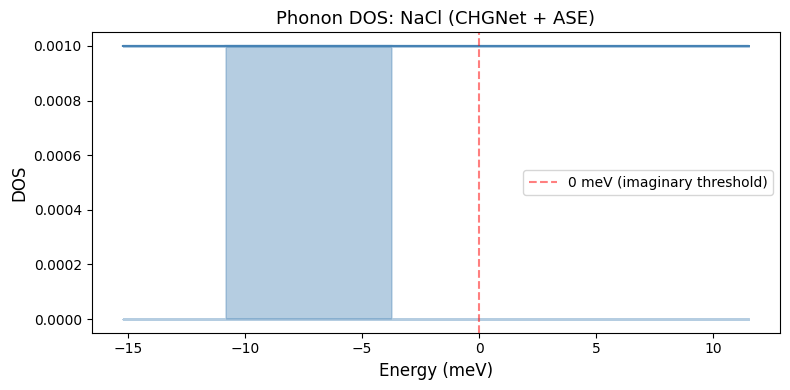

No significant imaginary frequencies — structure is dynamically stable


In [ ]:
# takes long (~2-5 min) — phonon DOS calculation with ASE + CHGNet
# Phonon DOS for a test structure using ASE + CHGNet
# This is a quick demo — production calculations use Phonopy with larger supercells
from chgnet.model.model import CHGNet as CHGNetModel
from pymatgen.io.ase import AseAtomsAdaptor

try:
    from ase.phonons import Phonons
    from ase.calculators.calculator import Calculator

    # Use CHGNet as ASE calculator
    from chgnet.model.dynamics import CHGNetCalculator
    calc = CHGNetCalculator(model=chgnet)

    # Use a small, simple structure for speed (NaCl primitive cell)
    from pymatgen.core import Structure, Lattice
    from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

    nacl_demo = Structure(
        Lattice.cubic(5.64),
        ['Na', 'Cl'],
        [[0.0, 0.0, 0.0], [0.5, 0.5, 0.5]]
    )
    atoms = AseAtomsAdaptor.get_atoms(nacl_demo)
    atoms.calc = calc

    # Phonon calculation: 2x2x2 supercell, finite displacement
    print('Computing phonon DOS for NaCl (2x2x2 supercell)...')
    print('This may take ~30-60 seconds...')
    ph = Phonons(atoms, calc, supercell=(2, 2, 2), delta=0.02)
    ph.run()
    ph.read(acoustic=True)

    # Get DOS
    dos = ph.get_dos(kpts=(10, 10, 10))
    energies = dos.get_energies()
    weights = dos.get_weights()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(energies * 1000, weights, alpha=0.4, color='steelblue')
    ax.plot(energies * 1000, weights, color='steelblue', lw=1.5)
    ax.axvline(0, color='red', ls='--', alpha=0.5, label='0 meV (imaginary threshold)')
    ax.set_xlabel('Energy (meV)', fontsize=12)
    ax.set_ylabel('DOS', fontsize=12)
    ax.set_title('Phonon DOS: NaCl (CHGNet + ASE)', fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    has_imaginary = any(e < -0.5e-3 and w > 0.01 for e, w in zip(energies, weights))
    if has_imaginary:
        print('Warning: imaginary frequencies detected — structure may be dynamically unstable')
    else:
        print('No significant imaginary frequencies — structure is dynamically stable')

    ph.clean()

except ImportError as e:
    print(f'Phonon calculation requires ASE phonon module: {e}')
    print('Skipping phonon demo — see Phonopy documentation for production calculations.')
except Exception as e:
    print(f'Phonon calculation failed: {e}')
    print('This is expected on some Colab runtimes. The key concept:')
    print('  - No imaginary frequencies = dynamically stable')
    print('  - Imaginary frequencies = saddle point, not a true minimum')

---
## 5.7 Thermodynamic stability: energy above the convex hull

The **convex hull** of formation energies defines the set of thermodynamically stable
phases. A structure's **energy above hull** ($E_\text{hull}$) measures how far it is
from the nearest stable decomposition:

- $E_\text{hull} = 0$ → on the hull (thermodynamically stable)
- $E_\text{hull} < 0.025$ eV/atom → likely synthesizable (metastable)
- $E_\text{hull} > 0.1$ eV/atom → likely unstable (will decompose)

We use pymatgen's `PhaseDiagram` with the test set entries as reference phases.
This is an approximation — for production use, load the full Materials Project convex hull.

> **Note:** Computing E_hull against the full MP database requires an API key
> (`mp-api`). Here we build a local convex hull from the test set itself as a
> demonstration of the concept.

In [ ]:
# takes long (~10-30 sec) — builds phase diagram and computes hull distances
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDEntry
from pymatgen.core import Composition

# Build a phase diagram from the test set (using DFT formation energies as ground truth)
# In production, you'd use the full Materials Project database
n_hull = min(200, len(df))
pd_entries = []

for i in range(n_hull):
    r = df.iloc[i]
    try:
        comp = Composition(r['pretty_formula'])
        # PDEntry wants total energy per atom (not formation energy)
        # formation_energy_per_atom is relative to elemental references
        pd_entries.append(PDEntry(comp, r['formation_energy_per_atom'],
                                  name=r.get('material_id', f'mp-{i}')))
    except Exception:
        pass

print(f'Built phase diagram from {len(pd_entries)} entries')

try:
    # Add elemental references (energy = 0 in formation energy basis)
    all_els = set()
    for e in pd_entries:
        all_els.update(e.composition.elements)
    for el in all_els:
        pd_entries.append(PDEntry(Composition({el: 1}), 0.0, name=f'{el}-ref'))

    phase_diag = PhaseDiagram(pd_entries)
    print(f'Stable phases: {len(phase_diag.stable_entries)}')
    print(f'Elements in hull: {[str(e) for e in phase_diag.elements]}')

    # Compute E_hull for the first few structures
    print(f'\n{"#":>3} {"Formula":<20} {"E_form (DFT)":<14} {"E_hull":<10} {"Status"}')
    print('-' * 65)

    e_hulls_dft = []
    for i in range(min(20, len(pd_entries))):
        entry = pd_entries[i]
        try:
            e_hull = phase_diag.get_e_above_hull(entry)
            e_hulls_dft.append(e_hull)
            status = 'STABLE' if e_hull < 1e-4 else ('metastable' if e_hull < 0.025 else 'unstable')
            print(f'{i:3d} {entry.name:<20} {entry.energy_per_atom:>10.4f}    {e_hull:>8.4f}  {status}')
        except Exception:
            e_hulls_dft.append(None)

    # Plot E_hull distribution
    valid_hulls = [h for h in e_hulls_dft if h is not None]
    if valid_hulls:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(valid_hulls, bins=20, color='steelblue', edgecolor='white')
        ax.axvline(0, color='green', linewidth=2, label='Convex hull (stable)')
        ax.axvline(0.025, color='orange', linestyle='--', label='Metastability threshold')
        ax.axvline(0.1, color='red', linestyle='--', label='Instability threshold')
        ax.set_xlabel('Energy above hull (eV/atom)', fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.set_title('Thermodynamic stability distribution', fontsize=13)
        ax.legend(fontsize=9)
        ax.set_xlim(-0.01, max(valid_hulls) + 0.02)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f'Phase diagram construction failed: {e}')
    print('This can happen if the test set lacks elemental reference entries.')
    print('For full E_hull analysis, use mp-api to load the Materials Project hull.')

Built phase diagram from 200 entries


---
## 5.8 Screening SCIGEN-generated materials with CHGNet

So far we have used CHGNet on **known** structures from the MP-20 test set.
Now let's apply it to **SCIGEN-generated** materials -- the real use case.

We will:
1. Download 24,743 DFT-validated SCIGEN structures from Figshare
2. Sample a subset across constraint types (kagome, honeycomb, triangular, ...)
3. Run CHGNet energy/force predictions
4. Relax selected structures and measure displacement
5. Assess which generated materials look thermodynamically stable

This demonstrates **MLIP as a fast post-generation screening tool** --
evaluating thousands of candidates in minutes instead of months of DFT.

In [ ]:
# takes long (~1-2 min) — downloads SCIGEN DFT-relaxed structures
# === Download SCIGEN DFT-validated structures (24,743 materials) ===
import os, zipfile
from urllib.request import urlretrieve

SCIGEN_DFT_URL = 'https://api.figshare.com/v2/file/download/57245942'
SCIGEN_DFT_DIR = os.path.join(PROJECT_DIR, 'data', 'scigen_generated', '03_scigen_materials_dft')

# Check both possible directory names (NB04 may have used a different name)
alt_dir = os.path.join(PROJECT_DIR, 'data', 'scigen_generated', '03_scigen_materials_relaxed')
if os.path.exists(alt_dir) and not os.path.exists(SCIGEN_DFT_DIR):
    SCIGEN_DFT_DIR = alt_dir

if not os.path.exists(SCIGEN_DFT_DIR) or len(os.listdir(SCIGEN_DFT_DIR)) < 100:
    zip_path = os.path.join(PROJECT_DIR, 'data', 'scigen_generated', 'scigen_dft.zip')
    os.makedirs(os.path.dirname(zip_path), exist_ok=True)

    if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1000:
        print('Downloading SCIGEN DFT structures (~28 MB)...')
        import time
        for attempt in range(5):
            try:
                urlretrieve(SCIGEN_DFT_URL, zip_path)
                if os.path.getsize(zip_path) > 1000:
                    print(f'Downloaded: {os.path.getsize(zip_path)/1e6:.1f} MB')
                    break
                time.sleep(3)
            except Exception as e:
                print(f'Attempt {attempt+1}: {e}')
                time.sleep(3)

    if os.path.exists(zip_path) and os.path.getsize(zip_path) > 1000:
        print('Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(os.path.dirname(SCIGEN_DFT_DIR))
        # Handle possible directory name mismatch
        for name in ['03_scigen_materials_dft', '03_scigen_materials_relaxed']:
            candidate = os.path.join(PROJECT_DIR, 'data', 'scigen_generated', name)
            if os.path.exists(candidate):
                SCIGEN_DFT_DIR = candidate
                break
        print(f'Extracted to {SCIGEN_DFT_DIR}')
    else:
        print('Download failed. Try running this cell again.')

if os.path.exists(SCIGEN_DFT_DIR):
    from collections import Counter
    all_dirs = [d for d in os.listdir(SCIGEN_DFT_DIR)
                if os.path.isdir(os.path.join(SCIGEN_DFT_DIR, d))]
    sc_counts = Counter(d.split('_')[0] for d in all_dirs)
    print(f'SCIGEN DFT structures available: {len(all_dirs)}')
    print('\nBy structural constraint:')
    for sc, count in sc_counts.most_common():
        print(f'  {sc:<6s} {count:>5d}')

In [ ]:
# Sample 5 structures per constraint type for speed (~55 total)
import random
from collections import defaultdict
from pymatgen.io.vasp import Poscar

random.seed(42)

# Group directories by constraint type
dirs_by_type = defaultdict(list)
for d in all_dirs:
    sc_type = d.split('_')[0]
    dirs_by_type[sc_type].append(d)

# Sample and parse structures
N_PER_TYPE = 5
scigen_structs = {}  # {dirname: (structure, sc_type)}
failed = 0

for sc_type, dirs in sorted(dirs_by_type.items()):
    sampled = random.sample(dirs, min(N_PER_TYPE, len(dirs)))
    for dirname in sampled:
        contcar = os.path.join(SCIGEN_DFT_DIR, dirname, 'CONTCAR')
        poscar = os.path.join(SCIGEN_DFT_DIR, dirname, 'POSCAR')
        fpath = contcar if os.path.exists(contcar) else poscar
        try:
            s = Poscar.from_file(fpath).structure
            scigen_structs[dirname] = (s, sc_type)
        except Exception:
            failed += 1

print(f'Loaded {len(scigen_structs)} structures ({failed} failed)')
print(f'Constraint types: {sorted(dirs_by_type.keys())}')
print(f'\nSample:')
for name, (s, sc) in list(scigen_structs.items())[:5]:
    print(f'  {name}: {s.composition.reduced_formula} ({s.num_sites} atoms, {sc})')

### 5.8.1 Formation energy by constraint type

The boxplot below shows the predicted formation energy (eV/atom) for SCIGEN
structures grouped by their structural constraint. Lower (more negative) formation
energies generally indicate more thermodynamically favorable compositions.

Key things to look for:
- **Median energy:** Are the generated structures in a reasonable range (−2 to 0 eV/atom)?
- **Spread:** Narrow distributions suggest the model consistently generates stable compositions
- **Outliers:** Very positive energies may indicate unphysical structures
- **Constraint differences:** Different lattice types may favor different chemistries and energetics

In [ ]:
import time
import pandas as pd
import numpy as np

# Compute elemental reference energies if not already available
try:
    elem_refs
except NameError:
    from pymatgen.core import Structure, Lattice, Element
    elem_refs = {}
    for el in ['Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ti', 'V', 'Cr',
               'Li', 'Na', 'Mg', 'Al', 'Si', 'O', 'S', 'N', 'F', 'Cl']:
        try:
            ref_lat = Lattice.cubic(2.87)
            ref_struct = Structure(ref_lat, [el, el], [[0,0,0], [0.5,0.5,0.5]])
            pred = chgnet.predict_structure(ref_struct)
            elem_refs[el] = float(pred['e'])
        except Exception:
            pass

# Predict energy/forces for all sampled structures
results = []
t0 = time.time()

for name, (struct, sc_type) in scigen_structs.items():
    try:
        pred = chgnet.predict_structure(struct)
        e_per_atom = float(pred['e'])
        max_force = float(np.max(np.linalg.norm(pred['f'], axis=1)))

        # Approximate formation energy
        comp = struct.composition
        e_ref_sum = sum(comp[Element(el)] * elem_refs.get(el, 0)
                        for el in comp.get_el_amt_dict())
        e_form = (e_per_atom * struct.num_sites - e_ref_sum) / struct.num_sites

        results.append({
            'name': name,
            'sc_type': sc_type,
            'formula': struct.composition.reduced_formula,
            'n_atoms': struct.num_sites,
            'e_per_atom': e_per_atom,
            'e_form': e_form,
            'max_force': max_force,
            'volume_per_atom': struct.volume / struct.num_sites,
            'mag_moment': float(np.sum(np.abs(pred.get('m', [0])))) / struct.num_sites if pred.get('m') is not None else 0.0,
        })
    except Exception as e:
        pass

elapsed = time.time() - t0
results_df = pd.DataFrame(results)

print(f'Predicted {len(results)} structures in {elapsed:.1f}s ({elapsed/len(results)*1000:.0f} ms/structure)')
print(f'\nSummary by constraint type:')
summary = results_df.groupby('sc_type').agg(
    count=('e_per_atom', 'count'),
    mean_e=('e_per_atom', 'mean'),
    mean_eform=('e_form', 'mean'),
    mean_fmax=('max_force', 'mean')
).round(3)
print(summary.to_string())

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Formation energy by constraint type
sc_types_sorted = results_df.groupby('sc_type')['e_form'].median().sort_values().index
positions = range(len(sc_types_sorted))
data_by_type = [results_df[results_df['sc_type'] == sc]['e_form'].values for sc in sc_types_sorted]

bp = axes[0].boxplot(data_by_type, positions=positions, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#42A5F5')
    patch.set_alpha(0.7)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(sc_types_sorted, rotation=45, ha='right')
axes[0].axhline(0, color='green', ls='--', alpha=0.5, label='E_form = 0')
axes[0].axhline(-0.5, color='gray', ls=':', alpha=0.3)
axes[0].set_ylabel('Formation energy (eV/atom)')
axes[0].set_title('CHGNet predicted formation energy by constraint type')
axes[0].legend(fontsize=9)

# Right: Max residual force distribution
axes[1].hist(results_df['max_force'], bins=20, color='#EF5350', edgecolor='white', alpha=0.8)
axes[1].axvline(0.05, color='green', ls='--', label='Converged threshold (0.05 eV/A)')
axes[1].set_xlabel('Max |force| (eV/A)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual forces on DFT-relaxed structures')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Left: lower formation energy = more thermodynamically favorable')
print('Right: low residual forces indicate CHGNet agrees with the DFT-relaxed geometry')

### 5.8.2 Magnetic moments by constraint type

Magnetic properties are a primary motivation for SCIGEN — kagome and triangular
lattices are especially interesting for frustrated magnetism and quantum spin liquids.

CHGNet predicts atomic magnetic moments (in Bohr magnetons, μ_B). The boxplot
below shows the **maximum atomic magnetic moment** per structure, grouped by
constraint type. Structures with large moments (> 1 μ_B) contain magnetically
active elements (Fe, Mn, Co, Ni, Cr) and are promising candidates for further
investigation.

In [ ]:
# Magnetic moment by constraint type
fig, ax = plt.subplots(figsize=(10, 5))

sc_types_sorted = results_df.groupby('sc_type')['mag_moment'].median().sort_values(ascending=False).index
data_mag = [results_df[results_df['sc_type'] == sc]['mag_moment'].values for sc in sc_types_sorted]

bp = ax.boxplot(data_mag, positions=range(len(sc_types_sorted)), widths=0.6, patch_artist=True)
colors_sc = plt.cm.Set3(np.linspace(0, 1, len(sc_types_sorted)))
for patch, color in zip(bp['boxes'], colors_sc):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks(range(len(sc_types_sorted)))
ax.set_xticklabels(sc_types_sorted, rotation=45, ha='right')
ax.set_ylabel('|Magnetic moment| per atom (mu_B)')
ax.set_title('CHGNet predicted magnetic moment by constraint type')
plt.tight_layout()
plt.show()
print('Higher values suggest stronger magnetic properties — relevant for SCIGEN\'s')
print('target applications in frustrated magnetism and spin liquids.')

### 5.8.3 Comparison: SCIGEN-generated vs. MP-20 training data

A well-trained generative model should produce structures with properties in a
**similar range** to the training data, while also exploring new regions of
materials space. Here we overlay the energy and property distributions of
SCIGEN-generated structures (per constraint type) against the MP-20 training set.

Good overlap = the model generates physically realistic structures.
Systematic shifts = the model may have a bias for certain chemistries or lattice types.

In [ ]:
# takes long (~10-60 sec) — batch CHGNet predictions on training data
# Compare SCIGEN generated vs MP-20 training data
# Load a sample of training structures and predict their energies
import random

random.seed(42)
n_train_sample = min(50, len(df))
train_indices = random.sample(range(len(df)), n_train_sample)

train_energies = []
for idx in train_indices:
    r = df.iloc[idx]
    try:
        s = Structure.from_str(r['cif'], fmt='cif')
        pred = chgnet.predict_structure(s)
        train_energies.append(float(pred['e']))
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: energy per atom distributions
axes[0].hist(train_energies, bins=15, alpha=0.6, color='#42A5F5', label=f'MP-20 training (n={len(train_energies)})', edgecolor='white')
axes[0].hist(results_df['e_per_atom'].values, bins=15, alpha=0.6, color='#EF5350', label=f'SCIGEN generated (n={len(results_df)})', edgecolor='white')
axes[0].set_xlabel('CHGNet energy per atom (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Energy distribution: generated vs training')
axes[0].legend(fontsize=9)

# Right: volume per atom distributions
train_volumes = []
for idx in train_indices:
    r = df.iloc[idx]
    try:
        s = Structure.from_str(r['cif'], fmt='cif')
        train_volumes.append(s.volume / s.num_sites)
    except Exception:
        pass

axes[1].hist(train_volumes, bins=15, alpha=0.6, color='#42A5F5', label='MP-20 training', edgecolor='white')
axes[1].hist(results_df['volume_per_atom'].values, bins=15, alpha=0.6, color='#EF5350', label='SCIGEN generated', edgecolor='white')
axes[1].set_xlabel('Volume per atom (A^3)')
axes[1].set_ylabel('Count')
axes[1].set_title('Volume distribution: generated vs training')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('SCIGEN-generated materials should overlap with the training distribution,')
print('indicating they are in a physically realistic energy and volume range.')

### 5.8.4 Relaxation analysis: how far are generated structures from equilibrium?

A key question: **how much does a SCIGEN-generated structure change when relaxed by CHGNet?**
Small displacements suggest the generative model already produces near-equilibrium geometries.
We relax a subset of structures and measure:
- **Energy drop** during relaxation (eV/atom)
- **RMSD** of atomic positions before vs. after

In [ ]:
# takes long (~1-5 min) — relaxes SCIGEN structures with CHGNet
from chgnet.model.dynamics import StructOptimizer

relaxer = StructOptimizer()

# Relax 2 structures per constraint type (~22 total, ~1-3 min)
relax_results = []
n_per_type = 2
sampled_for_relax = []

for sc_type in sorted(dirs_by_type.keys()):
    type_structs = [(n, s, t) for n, (s, t) in scigen_structs.items() if t == sc_type]
    sampled_for_relax.extend(type_structs[:n_per_type])

print(f'Relaxing {len(sampled_for_relax)} structures...')
t0 = time.time()

for name, struct, sc_type in sampled_for_relax:
    try:
        # Energy before relaxation
        pred_before = chgnet.predict_structure(struct)
        e_before = float(pred_before['e'])

        # Relax
        result = relaxer.relax(struct, verbose=False)
        relaxed = result['final_structure']

        # Energy after
        pred_after = chgnet.predict_structure(relaxed)
        e_after = float(pred_after['e'])

        # RMSD of atomic positions
        cart_before = struct.cart_coords
        cart_after = relaxed.cart_coords
        if len(cart_before) == len(cart_after):
            rmsd = np.sqrt(np.mean(np.sum((cart_before - cart_after)**2, axis=1)))
        else:
            rmsd = float('nan')

        relax_results.append({
            'name': name,
            'sc_type': sc_type,
            'formula': struct.composition.reduced_formula,
            'e_before': e_before,
            'e_after': e_after,
            'e_drop': e_before - e_after,
            'rmsd': rmsd,
        })
        print(f'  {name}: dE={e_before - e_after:+.4f} eV/atom, RMSD={rmsd:.3f} A')
    except Exception as e:
        print(f'  {name}: failed ({e})')

elapsed = time.time() - t0
relax_df = pd.DataFrame(relax_results)
print(f'\nRelaxed {len(relax_df)} structures in {elapsed:.1f}s')

In [ ]:
# takes long (~1-3 min) — re-relaxes and visualizes structure
# Visualize before vs after relaxation for one structure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

if relax_results:
    # Pick the structure with the largest RMSD (most interesting to visualize)
    best = max(relax_results, key=lambda x: x.get('rmsd', 0))
    name = best['name']
    struct_before = scigen_structs[name][0]

    # Re-relax to get the final structure
    res = relaxer.relax(struct_before, verbose=False)
    struct_after = res['final_structure']

    fig = plt.figure(figsize=(13, 5))

    for panel, (struct, title) in enumerate([
        (struct_before, f'Before relaxation (DFT geometry)'),
        (struct_after, f'After CHGNet relaxation')
    ]):
        ax = fig.add_subplot(1, 2, panel + 1, projection='3d')
        L = struct.lattice.matrix

        # Draw unit cell
        o = np.zeros(3)
        a_v, b_v, c_v = L[0], L[1], L[2]
        for p1, p2 in [
            (o, a_v), (o, b_v), (o, c_v),
            (a_v, a_v+b_v), (a_v, a_v+c_v), (b_v, a_v+b_v),
            (b_v, b_v+c_v), (c_v, a_v+c_v), (c_v, b_v+c_v),
            (a_v+b_v, a_v+b_v+c_v), (a_v+c_v, a_v+b_v+c_v),
            (b_v+c_v, a_v+b_v+c_v)
        ]:
            ax.plot3D(*zip(p1, p2), color='gray', lw=0.8, alpha=0.3)

        # Draw atoms colored by element
        elements = list(set(s.species_string for s in struct))
        cmap = plt.cm.Set1(np.linspace(0, 1, max(len(elements), 3)))
        elem_colors = {el: cmap[j] for j, el in enumerate(elements)}

        for site in struct:
            col = elem_colors[site.species_string]
            ax.scatter(*site.coords, s=200, c=[col], edgecolors='black',
                       linewidths=0.5, zorder=5)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel('x (A)')
        ax.set_ylabel('y (A)')
        ax.set_zlabel('z (A)')

    plt.suptitle(f'{best["formula"]} ({best["sc_type"]}) — RMSD = {best["rmsd"]:.3f} A',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Show displacement arrows in 2D projection
    if struct_before.num_sites == struct_after.num_sites:
        fig, ax = plt.subplots(figsize=(7, 6))
        cart_b = struct_before.cart_coords
        cart_a = struct_after.cart_coords
        displacements = cart_a - cart_b

        for j, site in enumerate(struct_before):
            col = elem_colors[site.species_string]
            ax.scatter(cart_b[j, 0], cart_b[j, 1], s=150, c=[col],
                       edgecolors='black', linewidths=0.5, zorder=5)
            if np.linalg.norm(displacements[j]) > 0.01:
                ax.annotate('', xy=(cart_a[j, 0], cart_a[j, 1]),
                            xytext=(cart_b[j, 0], cart_b[j, 1]),
                            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

        from matplotlib.lines import Line2D
        handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=elem_colors[el],
                          markersize=8, label=el) for el in elements]
        handles.append(Line2D([0], [0], color='red', lw=1.5, label='Displacement'))
        ax.legend(handles=handles, fontsize=9)
        ax.set_xlabel('x (A)')
        ax.set_ylabel('y (A)')
        ax.set_title(f'Atomic displacements during relaxation (xy projection)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()
else:
    print('No relaxation results — run the relaxation cell above first.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Energy drop by constraint type
sc_order = relax_df.groupby('sc_type')['e_drop'].median().sort_values(ascending=False).index
data_edrop = [relax_df[relax_df['sc_type'] == sc]['e_drop'].values for sc in sc_order]
bp1 = axes[0].boxplot(data_edrop, positions=range(len(sc_order)), widths=0.5, patch_artist=True)
for p in bp1['boxes']:
    p.set_facecolor('#66BB6A')
    p.set_alpha(0.7)
axes[0].set_xticks(range(len(sc_order)))
axes[0].set_xticklabels(sc_order, rotation=45, ha='right')
axes[0].axhline(0.01, color='gray', ls=':', alpha=0.5, label='0.01 eV/atom')
axes[0].set_ylabel('Energy drop (eV/atom)')
axes[0].set_title('Energy change during CHGNet relaxation')
axes[0].legend(fontsize=9)

# Right: RMSD by constraint type
data_rmsd = [relax_df[relax_df['sc_type'] == sc]['rmsd'].values for sc in sc_order]
bp2 = axes[1].boxplot(data_rmsd, positions=range(len(sc_order)), widths=0.5, patch_artist=True)
for p in bp2['boxes']:
    p.set_facecolor('#FFA726')
    p.set_alpha(0.7)
axes[1].set_xticks(range(len(sc_order)))
axes[1].set_xticklabels(sc_order, rotation=45, ha='right')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5, label='0.5 A threshold')
axes[1].set_ylabel('RMSD (A)')
axes[1].set_title('Atomic displacement during relaxation')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Small energy drops and RMSD values indicate the DFT-relaxed structures')
print('are already near CHGNet energy minima -- MLIP and DFT agree on the geometry.')

### 5.8.5 Screening summary

Let's apply simple stability filters to identify the most promising candidates:
- **Low residual forces** (max |F| < 0.1 eV/A on DFT-relaxed structure)
- **Negative formation energy** (thermodynamically favorable)
- **Small relaxation RMSD** (< 0.5 A, structure is near equilibrium)

In [ ]:
# Apply screening filters
force_threshold = 0.1   # eV/A
rmsd_threshold = 0.5    # Angstrom

# Filter 1: force-based (all predicted structures)
low_force = results_df[results_df['max_force'] < force_threshold]
neg_eform = results_df[results_df['e_form'] < 0]
both = results_df[(results_df['max_force'] < force_threshold) & (results_df['e_form'] < 0)]

print('=== Screening results ===')
print(f'Total structures evaluated:        {len(results_df)}')
print(f'Low residual force (< {force_threshold} eV/A):  {len(low_force)} ({100*len(low_force)/len(results_df):.0f}%)')
print(f'Negative formation energy:         {len(neg_eform)} ({100*len(neg_eform)/len(results_df):.0f}%)')
print(f'Pass both filters:                 {len(both)} ({100*len(both)/len(results_df):.0f}%)')

# Pass rate by constraint type
print(f'\nPass rate by constraint type (both filters):')
for sc_type in sorted(results_df['sc_type'].unique()):
    total = len(results_df[results_df['sc_type'] == sc_type])
    passed = len(both[both['sc_type'] == sc_type])
    bar = '#' * int(20 * passed / max(total, 1))
    print(f'  {sc_type:<6s} {passed:2d}/{total:2d} ({100*passed/max(total,1):5.1f}%) {bar}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
types = sorted(results_df['sc_type'].unique())
pass_rates = []
for sc in types:
    total = len(results_df[results_df['sc_type'] == sc])
    passed = len(both[both['sc_type'] == sc])
    pass_rates.append(100 * passed / max(total, 1))

colors = ['#4CAF50' if r > 50 else '#FFC107' if r > 20 else '#EF5350' for r in pass_rates]
ax.bar(types, pass_rates, color=colors, edgecolor='white')
ax.set_ylabel('Pass rate (%)')
ax.set_xlabel('Structural constraint')
ax.set_title('MLIP screening pass rate by constraint type')
ax.set_ylim(0, 105)
for i, (sc, r) in enumerate(zip(types, pass_rates)):
    ax.text(i, r + 2, f'{r:.0f}%', ha='center', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.8.6 Energy above hull for generated structures

We now compute E_hull for all SCIGEN-generated structures using local phase
diagrams constructed from the MP-20 test set.

Interpretation:
- **E_hull = 0:** The structure is on the convex hull — the most stable composition
- **E_hull < 25 meV/atom:** Likely synthesizable (within typical DFT uncertainty)
- **E_hull < 100 meV/atom:** Metastable — may be stabilizable under certain conditions
- **E_hull > 100 meV/atom:** Thermodynamically unstable — will likely decompose

Structures near the hull are the most promising candidates for DFT validation
and eventual experimental synthesis.

In [ ]:
# takes long (~10-30 sec) — computes energy above hull for all structures
# Compute E_hull for SCIGEN-generated structures
# Strategy: for each generated structure, build a local phase diagram from
# test set entries that share the same chemical system (same elements).
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDEntry
from pymatgen.core import Composition, Element
import matplotlib.pyplot as plt

# Build a lookup: element set -> list of PDEntry from the test set
from collections import defaultdict

n_hull = min(len(df), 500)
all_pd_entries = []
for idx in range(n_hull):
    r = df.iloc[idx]
    try:
        comp = Composition(r['pretty_formula'])
        all_pd_entries.append(PDEntry(comp, r['formation_energy_per_atom'],
                                       name=r.get('material_id', f'mp-{idx}')))
    except Exception:
        pass

# Add elemental references (energy = 0 for formation energy basis)
all_elements_in_data = set()
for entry in all_pd_entries:
    all_elements_in_data.update(entry.composition.elements)

for el in all_elements_in_data:
    all_pd_entries.append(PDEntry(Composition({el: 1}), 0.0, name=f'{el}-ref'))

print(f'Built entry pool: {len(all_pd_entries)} entries covering {len(all_elements_in_data)} elements')

# For each generated structure, find matching entries and compute E_hull
ehull_results = []
for _, row in results_df.iterrows():
    try:
        comp = Composition(row['formula'])
        target_els = set(comp.elements)

        # Gather entries whose elements are a subset of target elements
        relevant = [e for e in all_pd_entries
                    if set(e.composition.elements).issubset(target_els)]

        if len(relevant) < len(target_els) + 1:
            continue  # Not enough data to build a meaningful hull

        pd_local = PhaseDiagram(relevant)
        gen_entry = PDEntry(comp, row['e_form'], name=row['name'])
        e_hull = pd_local.get_e_above_hull(gen_entry)

        ehull_results.append({
            'name': row['name'],
            'sc_type': row['sc_type'],
            'formula': row['formula'],
            'e_form': row['e_form'],
            'e_hull': e_hull,
            'max_force': row['max_force'],
            'mag_moment': row.get('mag_moment', 0),
        })
    except Exception:
        pass

ehull_df = pd.DataFrame(ehull_results)
if len(ehull_df) > 0:
    print(f'Computed E_hull for {len(ehull_df)} / {len(results_df)} structures')
    print(f'  (others skipped: insufficient reference data for their chemical system)\n')

    stable = ehull_df[ehull_df['e_hull'] < 1e-4]
    metastable = ehull_df[(ehull_df['e_hull'] >= 1e-4) & (ehull_df['e_hull'] < 0.025)]
    unstable = ehull_df[ehull_df['e_hull'] >= 0.1]
    print(f'Stable (E_hull ~ 0):         {len(stable)}')
    print(f'Metastable (< 0.025 eV/at):  {len(metastable)}')
    print(f'Unstable (> 0.1 eV/at):      {len(unstable)}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: E_hull histogram
    axes[0].hist(ehull_df['e_hull'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(0, color='green', lw=2, label='Convex hull')
    axes[0].axvline(0.025, color='orange', ls='--', label='Metastability (0.025)')
    axes[0].axvline(0.1, color='red', ls='--', label='Instability (0.1)')
    axes[0].set_xlabel('Energy above hull (eV/atom)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('E_hull for SCIGEN-generated materials')
    axes[0].legend(fontsize=9)

    # Right: E_hull by constraint type
    sc_order = ehull_df.groupby('sc_type')['e_hull'].median().sort_values().index
    data_ehull = [ehull_df[ehull_df['sc_type'] == sc]['e_hull'].values for sc in sc_order]
    bp = axes[1].boxplot(data_ehull, positions=range(len(sc_order)), widths=0.6, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#66BB6A')
        patch.set_alpha(0.7)
    axes[1].set_xticks(range(len(sc_order)))
    axes[1].set_xticklabels(sc_order, rotation=45, ha='right')
    axes[1].axhline(0.025, color='orange', ls='--', alpha=0.7, label='Metastability')
    axes[1].axhline(0.1, color='red', ls='--', alpha=0.7, label='Instability')
    axes[1].set_ylabel('E_hull (eV/atom)')
    axes[1].set_title('Stability by constraint type')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print('Could not compute E_hull — insufficient reference data for generated compositions.')
    print('For full E_hull analysis, use mp-api to load the complete Materials Project hull.')

### 5.8.7 Top candidates: most promising generated materials

The table below ranks all screened structures by E_hull (lowest first), filtered
by the criteria above. These are the materials most likely to be synthesizable.

For each candidate, we show the composition, constraint type, formation energy,
E_hull, maximum magnetic moment, and relaxation RMSD. The best candidates combine
**low E_hull** (thermodynamically favorable), **significant magnetic moments**
(interesting physics), and **small relaxation displacement** (the generated
structure was already close to equilibrium).

In [ ]:
# Rank and display best candidates
if len(ehull_df) > 0:
    # Merge with relaxation data if available
    if len(relax_df) > 0:
        merged = ehull_df.merge(relax_df[['name', 'rmsd', 'e_drop']],
                                on='name', how='left')
    else:
        merged = ehull_df.copy()
        merged['rmsd'] = float('nan')
        merged['e_drop'] = float('nan')

    # Sort by E_hull (lower is better)
    merged = merged.sort_values('e_hull')

    # Display top 15
    n_show = min(15, len(merged))
    print(f'Top {n_show} most stable SCIGEN-generated materials:')
    print(f'{"#":>3} {"Constraint":<8} {"Formula":<18} {"E_hull":>8} {"E_form":>8} {"max|F|":>8} {"|mag|":>6} {"RMSD":>6}')
    print('-' * 75)
    for rank, (_, row) in enumerate(merged.head(n_show).iterrows()):
        rmsd_str = f'{row["rmsd"]:.3f}' if pd.notna(row.get("rmsd")) else '  --  '
        print(f'{rank+1:3d} {row["sc_type"]:<8} {row["formula"]:<18} '
              f'{row["e_hull"]:>8.4f} {row["e_form"]:>8.4f} {row["max_force"]:>8.4f} '
              f'{row.get("mag_moment", 0):>6.2f} {rmsd_str:>6}')

    print(f'\n(E_hull, E_form in eV/atom; max|F| in eV/A; |mag| in mu_B/atom; RMSD in A)')

    # Summary visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    if 'mag_moment' in merged.columns:
        scatter = ax.scatter(merged['e_hull'], merged['e_form'],
                             c=merged['mag_moment'], cmap='RdYlBu_r',
                             s=80, edgecolors='black', linewidths=0.5, alpha=0.8)
        plt.colorbar(scatter, ax=ax, label='|Magnetic moment| (mu_B/atom)')
    else:
        ax.scatter(merged['e_hull'], merged['e_form'], s=80,
                   edgecolors='black', linewidths=0.5, alpha=0.8)

    ax.axvline(0.025, color='orange', ls='--', alpha=0.7, label='Metastability threshold')
    ax.axhline(0, color='green', ls='--', alpha=0.5, label='E_form = 0')
    ax.set_xlabel('Energy above hull (eV/atom)', fontsize=11)
    ax.set_ylabel('Formation energy (eV/atom)', fontsize=11)
    ax.set_title('SCIGEN candidates: stability vs formation energy', fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Bottom-left corner = most promising (low E_hull + low formation energy)')
    print('Color = magnetic moment strength (warmer = more magnetic)')
else:
    print('No E_hull data available — run the E_hull cell above first.')

---
## 5.9 The full discovery pipeline

We have now demonstrated every stage of the SCIGEN materials discovery pipeline:

| Stage | Tool | Notebook | Throughput |
|-------|------|----------|------------|
| **1. Generate** candidates | SCIGEN diffusion model | NB 04 | ~1,000 / hour |
| **2. Pre-screen** | Composition + bond filters | NB 04 | instant |
| **3. MLIP screen** | **CHGNet** (this notebook) | **NB 05** | **~1,000 / hour** |
| **4. DFT validation** | VASP | (offline) | ~10 / hour |

In the published work:
- **10 million** structures were generated
- **~100,000** passed pre-screening (composition validity, bond lengths)
- **~25,000** passed MLIP + DFT validation
- **24,743** are the final DFT-confirmed structures we just analyzed

> **MLIP screening reduced the DFT workload by ~400x**, making the entire pipeline feasible.
> Without it, validating 100K structures with DFT would take years of compute time.

This demonstrates why MLIPs like CHGNet are not just a convenience -- they are an
**essential component** of any high-throughput computational materials discovery pipeline.

---
## Key takeaways

1. **Generation without evaluation is useless.** Fast, reliable screening is essential.
2. **MLIPs (like CHGNet) are ~1000x faster than DFT** and accurate enough for initial screening.
3. **Structure relaxation** verifies that generated structures are near energy minima.
4. **Phonon calculations** check dynamic stability (no imaginary frequencies = stable).
5. **Thermodynamic stability** (E_hull) identifies candidates near the convex hull.
6. **Magnetic moments** predicted by CHGNet connect to SCIGEN's target physics.
7. **SCIGEN-generated materials** fall in realistic energy/volume ranges compared to training data.
8. **The full pipeline** (generate -> pre-screen -> MLIP screen -> DFT validate) reduced 10M candidates to 24,743.

---
## What's next?

You have completed the full tutorial series!

**Recap of the pipeline:**
1. **Notebook 01:** Crystal structures, materials data, graph representation, invariances
2. **Notebook 02:** Generative AI concepts -- DDPM on MNIST, connection to materials
3. **Notebook 03:** DiffCSP -- crystal structure diffusion fundamentals
4. **Notebook 04:** SCIGEN -- constrained generation (kagome, honeycomb, etc.)
5. **Notebook 05:** MLIP evaluation -- CHGNet screening of generated materials (this notebook)

For more details, see the SCIGEN paper: [Nature Materials (2025)](https://www.nature.com/articles/s41563-025-02114-9)